# **Project: Multiple Linear Regression model for Ad-campaign Sales**

The dataset contains information on advertising campaign expenditure across different media types, and the number of dollars generated in sales for the respective campaign.

The goal is to assess the relationship between all of the features (Tv,Radio,Newspaper and the Sales). Build a Multiple Linear Reg model and find how the Sales is getting effected (either increasing or decreasing) with all the features.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

#importing the data and reading it to a dataframe:
file_path = '/content/drive/MyDrive/Gen AI/Advertising Budget and Sales.csv'
adsales_df = pd.read_csv(file_path)
print(adsales_df)

     Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  \
0             1             230.1                 37.8   
1             2              44.5                 39.3   
2             3              17.2                 45.9   
3             4             151.5                 41.3   
4             5             180.8                 10.8   
..          ...               ...                  ...   
195         196              38.2                  3.7   
196         197              94.2                  4.9   
197         198             177.0                  9.3   
198         199             283.6                 42.0   
199         200             232.1                  8.6   

     Newspaper Ad Budget ($)  Sales ($)  
0                       69.2       22.1  
1                       45.1       10.4  
2                       69.3        9.3  
3                       58.5       18.5  
4                       58.4       12.9  
..                       ...        ...  
195      

## **Create Features & Label, and Split the data into Train & Test sets:**

In [3]:
#Create X, an array containing values of all features, and y, containing all values from the "sales" column
x = adsales_df.drop("Sales ($)", axis=1).values
y = adsales_df["Sales ($)"].values

In [4]:
# Import LinearRegression & Train/Test splits:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#Split the data into Train and Test sets:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)

## **Model fit and Predictions:**

In [5]:
# Instantiate the model:
reg = LinearRegression()

# Fit the model to the training data:
reg.fit(x_train, y_train)

# Make predictions for Sales using the Test features:
y_pred = reg.predict(x_test)
print("Prediction: {}, Actual Values : {}".format(y_pred[:2],y_test[:2]))

Prediction: [16.56581778 21.1804797 ], Actual Values : [16.9 22.4]


# **Evaluate Model Perormance**

Let's find out how well the features can explain the variance in the target values, along with assessing the model's ability to make predictions
on unseen data:

In [6]:
# Import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Import numpy for sqrt function

#Calculate the model's R-squared score by passing the test feature values and the test target values:
r_squared = reg.score(x_test, y_test)

# Compute RMSE:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the metrics
print("R-squared: {}".format(r_squared))
print("RMSE: {}".format(rmse))

R-squared: 0.8609155416329135
RMSE: 1.9487551567518948


Inference: The features explain 86.09% of the variance in sales values. Looks like this company's advertising strategy is working well.

**Note:**
If we're computing R-squared on our test set, the R-squared returned is dependent on the way that we split up the data. The data points in the
test set may have some peculiarities that mean the R-squared computed on it is not representative of the model's ability to generalize to unseen data. To combat this dependence on what is essentially a random split, we use a technique called cross-validation.

# **Cross-validation for R-squared:**

Cross-validation is a vital approach to evaluating a model. It maximizes the amount of data that is available to the model, as the model is not only trained but also tested on all of the available data.

So, here we build a linear regression model, then use 6-fold cross-validation to assess its accuracy for predicting sales using social media advertising expenditure. We will also display the individual score for each of the six-folds.

In [7]:
# Import the necessary modules
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Create a KFold object
kf = KFold(n_splits = 6, shuffle = True, random_state = 5)

reg = LinearRegression()

# Compute 6-fold cross-validation scores
cv_scores = cross_val_score(reg, x, y, cv = kf)

# Print scores
print(cv_scores)

[0.89488585 0.87851983 0.82806531 0.91920955 0.89588727 0.91264742]


Inference: Notice how R-squared for each fold ranged between 0.89 and 0.91. By using cross-validation, we can see how performance varies depending on how the data is split!

# **Analyzing cross-validation metrics:**

Now that we have performed cross-validation, it's time to analyze the results. Let's display the mean, standard deviation, and 95% confidence
interval for cv_results.

In [8]:
# Print the mean:
print(np.mean(cv_scores))

# Print the standard deviation:
print(np.std(cv_scores))

# Print the 95% confidence interval:
print(np.quantile(cv_scores, [0.025, 0.975]))

0.8882025369451232
0.02992476619478382
[0.83437212 0.91838928]


Inference: An average score of 0.888 is pretty good for a model out of the box. Now let's learn how to apply regularization to our regression
models.

**Note:**
Fitting a linear regression model minimizes a loss function to choose a coefficient, a, for each feature, and the intercept, b. If we allow these
coefficients to be very large, we can get overfitting. Therefore, it is common practice to alter (minimize) the loss function so that it penalizes
large coefficients. This is called regularization.

**Regularization** = penalizes large coefficients.

# **Ridge Regression:**
The first type of regularized regression is called ridge. With ridge, we use the Ordinary Least Squares (OLS) loss function plus the squared value
of each coefficient, multiplied by a constant, alpha.

When using ridge, we need to choose the best alpha value in order to fit and predict. Let's fit the ridge regression models over a range of different alpha values and print their scores. We will use all of the features in the dataset
to predict "sales".


In [10]:
# Import Ridge
from sklearn.linear_model import Ridge
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
ridge_scores = []
for alpha in alphas:
  # Create a Ridge regression model
  ridge = Ridge(alpha=alpha)

  # Fit the data
  ridge.fit(x_train, y_train)

  # Obtain R-squared
  score = ridge.score(x_test, y_test)
  ridge_scores.append(score)
print(ridge_scores)

[0.8609159266604678, 0.8609193914241943, 0.8609539911534568, 0.8612952311981992, 0.8642635660402205, 0.8690612131034828]


Inference: The scores don't appear to change much as alpha increases, which is indicative of how well the features explain the variance in the target-even by heavily penalizing large coefficients, underfitting does not occur.

**So, how do you identify the optimal features?**

Solution: use Lasso Regression.

## **Lasso regression for feature importance:**

We use Lasso regression to identify important features in a dataset.

Let's fit a lasso regression model to the data and plot the model's coefficients.

[-4.75634820e-04  4.57352266e-02  1.86478679e-01 -9.59144457e-05]


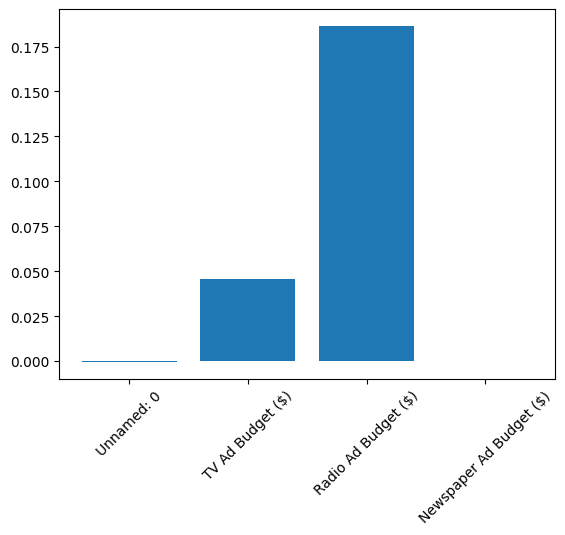

In [12]:
# Import Lasso
from sklearn.linear_model import Lasso

# Instantiate a lasso regression model
lasso = Lasso(alpha=0.3)

# Fit the model to the data
lasso.fit(x,y)

# Compute and print the coefficients
lasso_coef = lasso.fit(x,y).coef_
print(lasso_coef)
feature_names = adsales_df.columns[:len(lasso_coef)]

# Import matplotlib.pyplot
import matplotlib.pyplot as plt
plt.bar(feature_names, lasso_coef)
plt.xticks(rotation=45)
plt.show()

Inference: See how the figure makes it clear that expenditure on Radio advertising is the most important feature in the dataset to predict sales
values.